In [1]:
import numpy as np
import faiss
import pandas as pd

embeddings = np.load("data/unsplash/embeddings.npy")
ids = np.load("data/unsplash/ids.npy", allow_pickle=True)
index = faiss.read_index("data/unsplash/index.faiss")

df = pd.read_csv(
    "data/unsplash_lite/photos.csv",
    sep="\t",
    on_bad_lines="skip"
)

df = df.dropna(subset=["photo_image_url"])
df = df[df["photo_image_url"].str.startswith("https")]
df = df.reset_index(drop=True)

In [2]:
from functools import lru_cache
import requests
from PIL import Image
from io import BytesIO

# fast id → url mapping
id_to_url = dict(zip(df["photo_id"], df["photo_image_url"]))

@lru_cache(maxsize=2000)
def fetch_image(url):
    try:
        img = Image.open(BytesIO(requests.get(url, timeout=5).content)).convert("RGB")
        img.thumbnail((256, 256))
        return img
    except:
        return None

In [ ]:
import matplotlib.pyplot as plt

def show_results(i, k=3):
    plt.figure(figsize=(15, 3))

    # ---- query ----
    query_url = id_to_url[ids[i]]
    query_img = fetch_image(query_url)

    plt.subplot(1, k+1, 1)
    if query_img:
        plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    # ---- search ----
    query = embeddings[i].reshape(1, -1)
    distances, indices = index.search(query, k)

    # ---- results ----
    for j, idx in enumerate(indices[0]):
        url = id_to_url[ids[idx]]
        img = fetch_image(url)

        plt.subplot(1, k+1, j+2)
        if img:
            plt.imshow(img)
        plt.title(f"{distances[0][j]:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

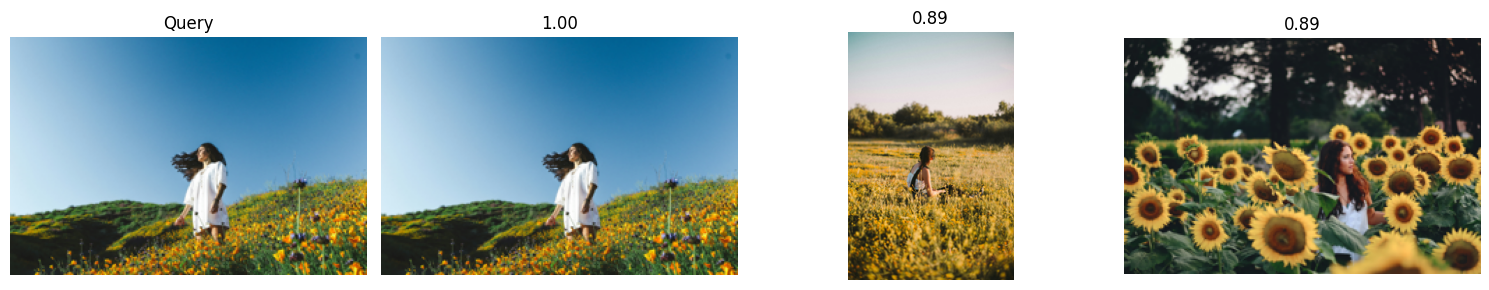

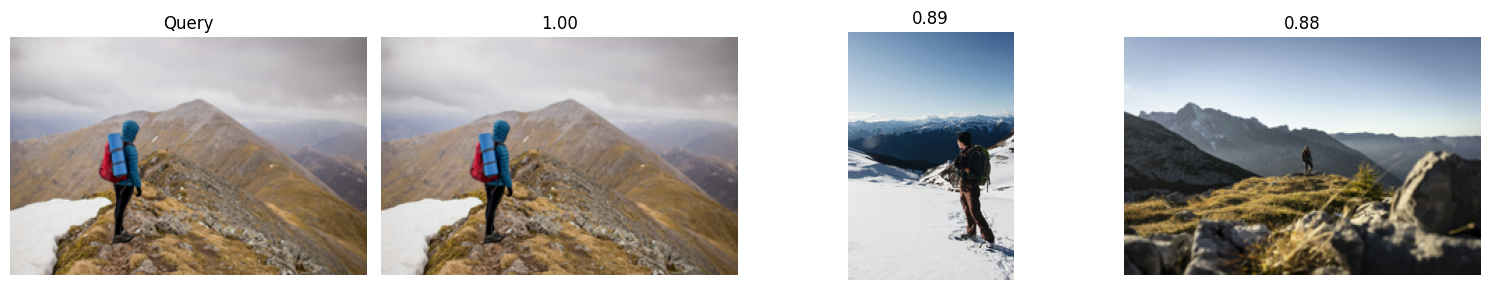

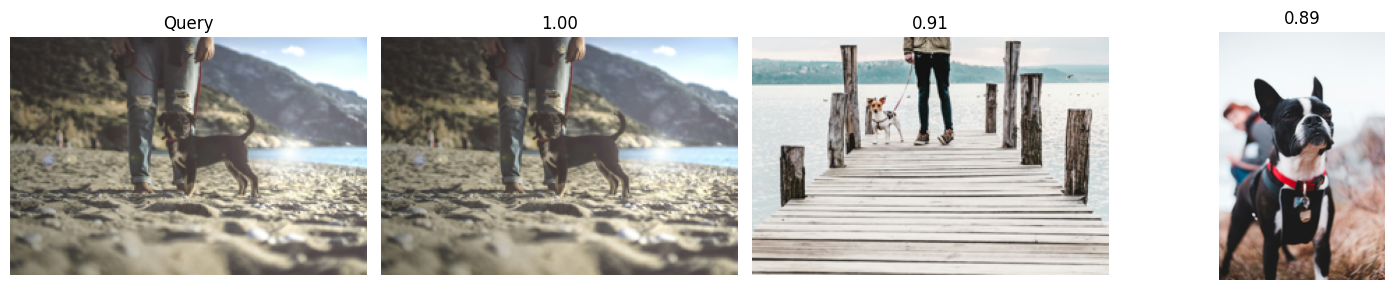

In [ ]:
show_results(10)
show_results(100)
show_results(500)